# 1. Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

In [ ]:
# lectura de los datos
proyecto_df = pd.read_excel('/content/data set Proyecto Final.xlsx')
proyecto_df.columns = proyecto_df.columns.str.strip().str.replace(',', '').str.replace(' ', '_').str.lower()
proyecto_df.head()

,desaño,desmes,h_construccion_$,h_refaccion_$,h_adquisición_nueva_$,h_adquisición_resto_$,h_otros_$,p_automotores_$,p_maquinarias_$,p-otros$,tipo_de_cambio,tasa_de_interes
0,2010.07,Jul.,4282081,152699,1544051,5660828,2220797,3837388,259273,1249680,3.934824,29.605238
1,2010.08,Ago.,4359798,153111,1550875,5703148,2259947,4014747,260441,1259990,3.937610,28.910476
2,2010.09,Set.,4005438,167185,886653,7049683,2247213,4597633,239637,1164202,3.951891,29.332273
3,2010.10,Oct.,4062383,168583,897503,7140713,2315940,4832333,250494,1193453,3.956984,29.608421
4,2010.11,Nov.,4127584,172567,906275,7226265,2411831,5125575,268533,1241870,3.967600,30.543810


In [ ]:
proyecto_df.describe()

,desaño,h_construccion_$,h_refaccion_$,h_adquisición_nueva_$,h_adquisición_resto_$,h_otros_$,p_automotores_$,p_maquinarias_$,p-otros$,tipo_de_cambio,tasa_de_interes
count,189.000000,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,189.000000,189.000000
mean,2017.938254,2.621550e+07,3.771733e+06,2.095437e+08,1.195724e+08,8.430568e+07,2.695213e+08,3.864622e+07,1.174013e+08,206.279592,53.790515
std,4.571042,5.475953e+07,7.470863e+06,5.686017e+08,3.243851e+08,2.378353e+08,6.325560e+08,8.426171e+07,2.790139e+08,390.162329,22.553534
min,2010.070000,2.207474e+06,1.526990e+05,8.866530e+05,5.660828e+06,2.220797e+06,3.837388e+06,2.396370e+05,1.164202e+06,3.934824,28.910476
25%,2014.060000,3.412578e+06,1.044559e+06,9.047150e+06,9.373211e+06,5.202887e+06,1.706154e+07,1.137943e+06,4.165550e+06,8.125515,37.498182
50%,2018.050000,9.000642e+06,2.045756e+06,9.263400e+07,2.957281e+07,1.550378e+07,4.445133e+07,6.112407e+06,8.479135e+06,23.668748,46.034737
75%,2022.040000,2.753194e+07,2.787504e+06,1.178265e+08,3.889502e+07,2.740872e+07,9.191814e+07,2.277430e+07,5.562232e+07,113.334474,67.652273
max,2026.030000,3.258690e+08,4.039955e+07,3.461931e+09,1.465120e+09,1.232587e+09,2.791996e+09,3.859431e+08,1.168717e+09,1449.334662,138.748947


In [ ]:
proyecto_tc = [col for col in proyecto_df.columns if col not in ["desaño", 'desmes',	"tipo_de_cambio",	"tasa_de_interes"]]
X = proyecto_df[proyecto_tc]
# Definimos nuestra Variables objetivos en este caso dos
y = proyecto_df[['tipo_de_cambio','tasa_de_interes']]


In [ ]:
proyecto_df

,desaño,desmes,h_construccion_$,h_refaccion_$,h_adquisición_nueva_$,h_adquisición_resto_$,h_otros_$,p_automotores_$,p_maquinarias_$,p-otros$,tipo_de_cambio,tasa_de_interes
0,2010.07,Jul.,4282081,152699,1544051,5660828,2220797,3837388,259273,1249680,3.934824,29.605238
1,2010.08,Ago.,4359798,153111,1550875,5703148,2259947,4014747,260441,1259990,3.937610,28.910476
2,2010.09,Set.,4005438,167185,886653,7049683,2247213,4597633,239637,1164202,3.951891,29.332273
3,2010.10,Oct.,4062383,168583,897503,7140713,2315940,4832333,250494,1193453,3.956984,29.608421
4,2010.11,Nov.,4127584,172567,906275,7226265,2411831,5125575,268533,1241870,3.967600,30.543810
...,...,...,...,...,...,...,...,...,...,...,...,...
184,2025.11,Nov.,245841780,36416480,2627351617,1448270759,1077965854,2649708173,371473569,1168576186,1427.617647,77.415294
185,2025.12,Dic.,267245331,37476893,2885100699,1459129261,1125179763,2650055482,375273934,1021428635,1447.837721,70.501053
186,2026.01,Ene.,287985700,38079771,3108850999,1459405911,1155672582,2693790016,385943093,1020452144,1449.334662,68.353333
187,2026.02,Feb.,305523547,38908207,3271729446,1461306787,1182184506,2739547068,375877862,1009885315,1409.657100,69.211667


In [ ]:
# Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Saclamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# svr multisalida
# juntamos el SRV dentro del MultiOutputRegressor
base_svr = SVR()
multi_svr = MultiOutputRegressor(base_svr)
#multi_svr.fit(X_train_scaled, y_train)
#y_pred = multi_svr.predict(X_test_scaled)

In [ ]:
param_grid = {
    'estimator__kernel': ['linear', 'rbf'],
    'estimator__C': [10, 100],
    #'estimator__gamma': ["scale", "auto"]
}
grid_search = GridSearchCV(multi_svr, param_grid, cv=3, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=MultiOutputRegressor(estimator=SVR()),
             param_grid={'estimator__C': [10, 100],
                         'estimator__kernel': ['linear', 'rbf']},
             scoring='r2')

In [ ]:
# Evaluamos el mejor modelo
best_model  = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

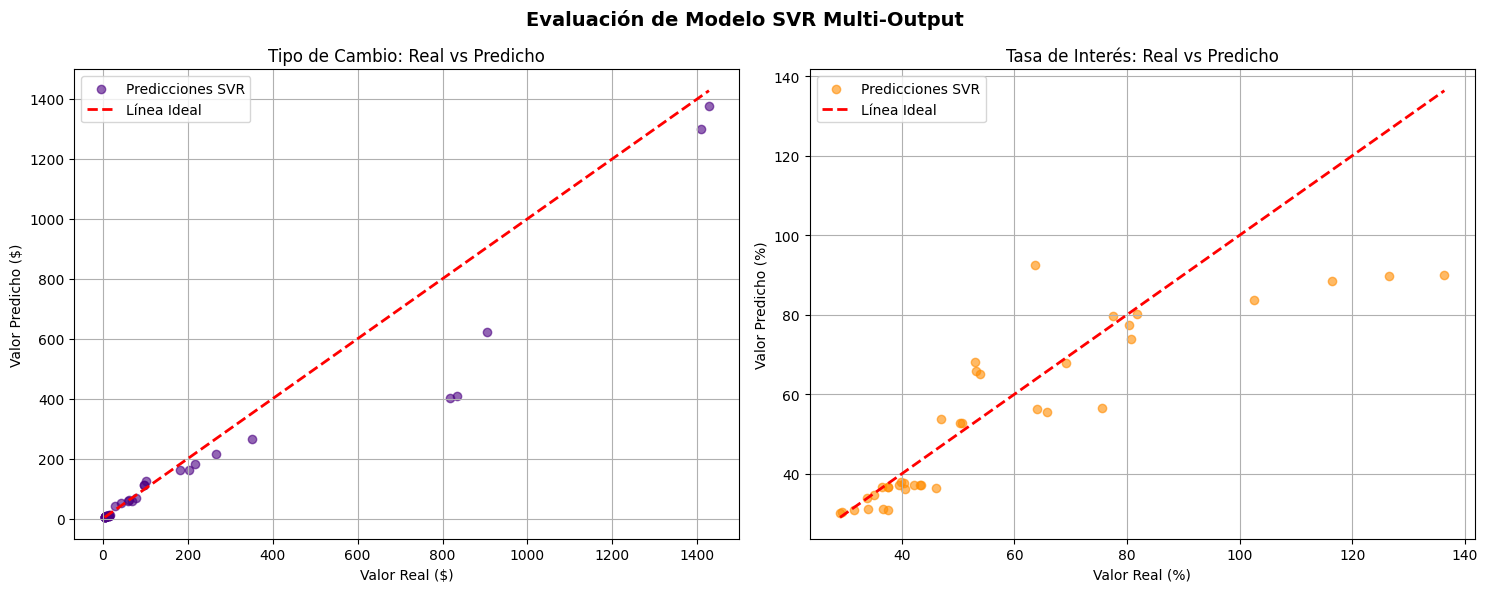

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#  Tipo de Cambio (Primera columna de la matriz: índice 0)
ax1.scatter(y_test.iloc[:, 0], y_pred[:, 0], color='indigo', alpha=0.6, label='Predicciones SVR')
ax1.plot([y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()],
         [y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()], 'r--', lw=2, label='Línea Ideal')
ax1.set_title('Tipo de Cambio: Real vs Predicho')
ax1.set_xlabel('Valor Real ($)')
ax1.set_ylabel('Valor Predicho ($)')
ax1.grid(True)
ax1.legend()

# Tasa de Interés (Segunda columna de la matriz: índice 1)
ax2.scatter(y_test.iloc[:, 1], y_pred[:, 1], color='darkorange', alpha=0.6, label='Predicciones SVR')
ax2.plot([y_test.iloc[:, 1].min(), y_test.iloc[:, 1].max()],
         [y_test.iloc[:, 1].min(), y_test.iloc[:, 1].max()], 'r--', lw=2, label='Línea Ideal')
ax2.set_title('Tasa de Interés: Real vs Predicho')
ax2.set_xlabel('Valor Real (%)')
ax2.set_ylabel('Valor Predicho (%)')
ax2.grid(True)
ax2.legend()

plt.suptitle('Evaluación de Modelo SVR Multi-Output', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Los puntos en la tasa de interes estan mas dispersos que en de tipo de cambio, se puede concluir que que el volumne de creditos tienen mayor correlacion y predictibilida sobre el tipo de cambio que sobre el tasa de interes.

In [ ]:
# ingresamos nuevos datos
nuevos_datos_credito = {

    "h_construccion_$": 172938217.5,      # Monto estimado para Construcción
    "h_refaccion_$": 26034760.5,          # Monto para Refacción
    "h_adquisición_nueva_$": 1452700721.00,# Compra Vivienda Nueva
    "h_adquisición_resto_$": 1205027010.33,# Compra Vivienda Usada
    "h_otros_$": 842888983.00,             # Otros créditos hipotecarios
    "p_automotores_$": 2211667820.75,      # Préstamos prendarios autos
    "p_maquinarias_$": 305978956.5,       # Préstamos prendarios Maquinaria
    "p-otros$": 1152284868.67              # Resto de los prestamos prendarios
}

In [ ]:
entrada_nueva = pd.DataFrame([nuevos_datos_credito])
entrada_nueva_scaled = scaler.transform(entrada_nueva)
prediccion = best_model.predict(entrada_nueva_scaled)

In [ ]:
t_cambio_predicha = prediccion[0][0]
t_interes_predicha = prediccion[0][1]

In [ ]:
print(f"\ Variables de Entrada Procesadas (Volumen de Crédito Solicitado).")
print(f"Predicción Macroeconómica del Modelo SVR:")
print(f"Tipo de Cambio Estimado:  ${t_cambio_predicha:.2f} ARS")
print(f"Tasa de Interés Estimada:  {t_interes_predicha:.2f}%")


# Lógica de decisión sugerida para la entrega
if t_interes_predicha > 65.0:
    print("RECOMENDACIÓN BANCARIA: ALERTA DE ESTRÉS. Las tasas proyectadas superan el 65%.")
    print("Acción: Congelar colocación de préstamos a tasa fija y exigir mayores garantías.")
else:
    print("RECOMENDACIÓN BANCARIA: ESCENARIO MODERADO. Tasas proyectadas bajo el umbral de riesgo.")
    print("Acción: Mantener la liquidez activa y promover líneas prendarias y prendarias cortas.")



[IN] Variables de Entrada Procesadas (Volumen de Crédito Solicitado).
[OUT] Predicción Macroeconómica del Modelo SVR:
      -> Tipo de Cambio Estimado:  $1253.30 ARS
      -> Tasa de Interés Estimada:  70.46%
------------------------------------------------------------
RECOMENDACIÓN BANCARIA: ALERTA DE ESTRÉS. Las tasas proyectadas superan el 65%.
Acción: Congelar colocación de préstamos a tasa fija y exigir mayores garantías.
